# 1. Controle: num_palavras fora do treinamento principal

Derivado diretamente de `anomaly-detection-fakebr.ipynb`, preservando leitura,
15 features, split por notícia, seed 42, imputação, Isolation Forest e avaliação.
`num_palavras` continua nos metadados e na extração de razões, mas é excluído
explicitamente da matriz de treino. A mesma exclusão vale para validação e teste.

**O notebook de origem já excluía essa contagem bruta.** Portanto, o treinamento
principal deve reproduzir o original. A seção 17 acrescenta um controle auxiliar
COM num_palavras, para medir a diferença de incluí-la diretamente; esse controle
nunca substitui o treinamento principal. Razões ainda podem depender do tamanho.
Anomalia não é sinônimo de falsidade.

**Google Colab:** faça upload deste `.ipynb` em Arquivo → Abrir notebook → Upload.
Use um ambiente Python de CPU e selecione Ambiente de execução → Executar tudo.
O notebook baixa o ZIP público do Fake.br em `data/`. Não precisa de Drive,
outros notebooks, arquivos `.py`, notícias JSON ou da pasta news-analysis.
As bibliotecas usuais já acompanham o Colab; as versões utilizadas são registradas.
Validado localmente em kernel limpo; a interface hospedada do Colab não foi testada.

## 2. Imports

Semente fixa de 42. As versões do ambiente ficam registradas para reprodução.

In [1]:
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile
from itertools import combinations
from importlib.metadata import version
import hashlib
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)

In [2]:
RANDOM_STATE = 42
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})
print("Python:", platform.python_version())
print({name: version(name) for name in ["numpy", "pandas", "scikit-learn", "matplotlib", "ipykernel"]})

Python: 3.12.10
{'numpy': '2.5.3', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.1', 'ipykernel': '7.3.0'}


## 3. Carregamento dos dados

Fonte: [Fake.br-Corpus](https://github.com/roneysco/Fake.br-Corpus), versão fixa
`780f5516c4ae070761632d98ac3368f3ded09d35`, diretório `full_texts`.
Os 25 campos seguem a ordem documentada pelo corpus. Lemos textos e `*-meta.txt`
diretamente do ZIP, sem extrair ou truncar notícias. IDs True recebem sufixo `t`,
como no original, para distinguir as classes. O merge valida correspondência 1:1.

Referência: Monteiro et al. (2018), *Contributions to the Study of Fake News in
Portuguese: New Corpus and Automatic Detection Results*, PROPOR 2018.

In [3]:
CORPUS_REVISION = "780f5516c4ae070761632d98ac3368f3ded09d35"
CORPUS_URL = f"https://codeload.github.com/roneysco/Fake.br-Corpus/zip/{CORPUS_REVISION}"
projectFolder = Path.cwd()
dataFolder = projectFolder / "data"
dataFolder.mkdir(exist_ok=True)
archivePath = dataFolder / f"Fake.br-Corpus-{CORPUS_REVISION}.zip"

if not archivePath.exists():
    temporaryPath = archivePath.with_suffix(".download")
    with urlopen(CORPUS_URL, timeout=120) as response, temporaryPath.open("wb") as target:
        while chunk := response.read(1024 * 1024):
            target.write(chunk)
    with ZipFile(temporaryPath) as archive:
        assert archive.testzip() is None, "ZIP corrompido; refaça o download."
    temporaryPath.replace(archivePath)

print("Corpus revision:", CORPUS_REVISION)
print("Archive SHA256:", hashlib.sha256(archivePath.read_bytes()).hexdigest())

Corpus revision: 780f5516c4ae070761632d98ac3368f3ded09d35
Archive SHA256: be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090


In [4]:
metadataColumns = [
    "autor", "link", "categoria", "data_publicacao",
    "num_tokens", "num_palavras", "num_types", "num_links", "num_maiusculas",
    "num_verbos", "num_verbos_subj_imp", "num_substantivos", "num_adjetivos",
    "num_adverbios", "num_verbos_modais", "num_pron_1_2_sing", "num_pron_1_plural",
    "num_pronomes", "pausalidade", "num_caracteres", "tam_medio_sentenca",
    "tam_medio_palavra", "pct_erros_ortograficos", "emotividade", "diversidade",
]

In [5]:
def loadNewsTexts(archive, folder, label):
    records = []
    for name in sorted(archive.namelist()):
        if f"/full_texts/{folder}/" not in name or not name.endswith(".txt"):
            continue
        articleId = Path(name).stem + ("t" if label == 0 else "")
        records.append({
            "id": articleId, "text": archive.read(name).decode("utf-8"),
            "label": label, "sourceClass": folder,
        })
    assert records, f"Nenhum texto encontrado em {folder}"
    return pd.DataFrame(records)


def loadNewsMetadata(archive, folder, label):
    records = []
    for name in sorted(archive.namelist()):
        if f"/full_texts/{folder}-meta-information/" not in name or not name.endswith("-meta.txt"):
            continue
        values = [line.strip() for line in archive.read(name).decode("utf-8").splitlines()]
        assert len(values) == len(metadataColumns), f"Esquema inesperado em {name}: {len(values)} linhas"
        articleId = Path(name).name.removesuffix("-meta.txt") + ("t" if label == 0 else "")
        records.append({**dict(zip(metadataColumns, values)), "id": articleId, "metadataLabel": label})
    assert records, f"Nenhum metadado encontrado em {folder}"
    return pd.DataFrame(records)

In [6]:
with ZipFile(archivePath) as archive:
    textsFrame = pd.concat([
        loadNewsTexts(archive, "fake", 1), loadNewsTexts(archive, "true", 0),
    ], ignore_index=True)
    metadataFrame = pd.concat([
        loadNewsMetadata(archive, "fake", 1), loadNewsMetadata(archive, "true", 0),
    ], ignore_index=True)

assert textsFrame["id"].is_unique and metadataFrame["id"].is_unique
assert set(textsFrame["id"]) == set(metadataFrame["id"]), "Texto/metadados sem correspondência"
newsFrame = textsFrame.merge(metadataFrame, on="id", validate="one_to_one", indicator=True)
assert newsFrame["_merge"].eq("both").all()
assert newsFrame["label"].eq(newsFrame["metadataLabel"]).all()
newsFrame = newsFrame.drop(columns=["_merge", "metadataLabel"])
assert newsFrame["text"].str.strip().ne("").all()
print(f"{len(newsFrame):,} notícias carregadas; textos e metadados correspondem 1:1.")

7,200 notícias carregadas; textos e metadados correspondem 1:1.


## 4. Contrato dos labels

**0 = True; 1 = Fake.** O rótulo forma as partições e permite avaliação externa.
Não entra como feature. A origem nas pastas também é verificada.

In [7]:
labelNames = {0: "True", 1: "Fake"}
assert labelNames == {0: "True", 1: "Fake"}
assert set(newsFrame["label"].unique()) == {0, 1}
assert newsFrame.loc[newsFrame["label"].eq(0), "sourceClass"].eq("true").all()
assert newsFrame.loc[newsFrame["label"].eq(1), "sourceClass"].eq("fake").all()
display(newsFrame.groupby(["label", "sourceClass"]).size().rename("newsCount").to_frame())

,,newsCount
label,sourceClass,
0,true,3600
1,fake,3600


## 5. Preparação dos metadados

Preservamos todos os campos brutos em `rawNewsFrame` e todas as contagens numéricas
em `newsFrame`. Valores não numéricos viram NaN com contagem explícita; nenhum
ausente é preenchido antes do treino. `tem_autor` segue a lógica do original:
ausência para string vazia, `None`, `none` ou `NULL`. Não é uma medida de credibilidade.

In [8]:
rawNewsFrame = newsFrame.copy(deep=True)
numericMetadataColumns = metadataColumns[4:]
convertedMetadata = newsFrame[numericMetadataColumns].apply(pd.to_numeric, errors="coerce")
conversionMissing = convertedMetadata.isna().sum().rename("missingAfterNumericConversion")
display(conversionMissing.to_frame())
newsFrame[numericMetadataColumns] = convertedMetadata
newsFrame["tem_autor"] = (~newsFrame["autor"].fillna("").astype(str).str.strip().isin(
    ["", "None", "none", "NULL"]
)).astype(int)

,missingAfterNumericConversion
num_tokens,0
num_palavras,0
num_types,0
num_links,1393
num_maiusculas,0
num_verbos,0
num_verbos_subj_imp,0
num_substantivos,0
num_adjetivos,0
num_adverbios,0


## 6. Feature Extraction

Todas as fórmulas são centralizadas. Denominadores zero, negativos ou não finitos
produzem NaN, nunca zero artificial. Ausentes serão tratados pela mediana de
**normalTrain** dentro do pipeline. `punctuationDensity` é uma aproximação de
tokens não-palavra, não uma contagem exata de pontuação.

In [9]:
def calculateRatio(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce").astype(float)
    denominator = pd.to_numeric(denominator, errors="coerce").astype(float)
    safeDenominator = denominator.where(denominator.gt(0) & np.isfinite(denominator))
    return numerator.div(safeDenominator).replace([np.inf, -np.inf], np.nan)

In [10]:
anomalyColumns = [
    "tem_autor", "typeTokenRatio", "adjectiveRatio", "adverbRatio", "pronounRatio",
    "modalVerbRatio", "imperativeSubjunctiveRatio", "personalPronounRatio",
    "linkDensity", "punctuationDensity", "uppercaseRatio", "pausalidade",
    "pct_erros_ortograficos", "emotividade", "diversidade",
]


def extractAnomalyFeatures(newsFrame):
    featuresFrame = newsFrame.copy()
    featuresFrame["typeTokenRatio"] = calculateRatio(newsFrame["num_types"], newsFrame["num_tokens"])
    featuresFrame["adjectiveRatio"] = calculateRatio(newsFrame["num_adjetivos"], newsFrame["num_palavras"])
    featuresFrame["adverbRatio"] = calculateRatio(newsFrame["num_adverbios"], newsFrame["num_palavras"])
    featuresFrame["pronounRatio"] = calculateRatio(newsFrame["num_pronomes"], newsFrame["num_palavras"])
    featuresFrame["modalVerbRatio"] = calculateRatio(newsFrame["num_verbos_modais"], newsFrame["num_verbos"])
    featuresFrame["imperativeSubjunctiveRatio"] = calculateRatio(newsFrame["num_verbos_subj_imp"], newsFrame["num_verbos"])
    featuresFrame["personalPronounRatio"] = calculateRatio(
        newsFrame["num_pron_1_2_sing"] + newsFrame["num_pron_1_plural"], newsFrame["num_pronomes"],
    )
    featuresFrame["linkDensity"] = calculateRatio(newsFrame["num_links"], newsFrame["num_palavras"])
    featuresFrame["punctuationDensity"] = calculateRatio(
        newsFrame["num_tokens"] - newsFrame["num_palavras"], newsFrame["num_tokens"],
    )
    featuresFrame["uppercaseRatio"] = calculateRatio(newsFrame["num_maiusculas"], newsFrame["num_palavras"])
    return featuresFrame

In [11]:
featuresFrame = extractAnomalyFeatures(newsFrame)
featuresFrame[anomalyColumns] = featuresFrame[anomalyColumns].replace([np.inf, -np.inf], np.nan)
display(featuresFrame[anomalyColumns].isna().sum().rename("missingCount").to_frame())

,missingCount
tem_autor,0
typeTokenRatio,0
adjectiveRatio,0
adverbRatio,0
pronounRatio,0
modalVerbRatio,0
imperativeSubjunctiveRatio,0
personalPronounRatio,67
linkDensity,1393
punctuationDensity,0


## 7. Sanity checks

Validamos a lista de 15 features, tipos numéricos, ausência de infinitos e
preservação das contagens. NaN é permitido antes do imputer; IDs e labels são
excluídos explicitamente. Os testes de partição aparecem após a divisão.

In [12]:
assert "label" not in anomalyColumns
assert "id" not in anomalyColumns
assert len(anomalyColumns) == len(set(anomalyColumns)) == 15
assert featuresFrame["id"].is_unique
assert all(pd.api.types.is_numeric_dtype(featuresFrame[name]) for name in anomalyColumns)
assert not np.isinf(featuresFrame[anomalyColumns].to_numpy(dtype=float)).any()
pd.testing.assert_frame_equal(featuresFrame[numericMetadataColumns], newsFrame[numericMetadataColumns])
ratioCheck = calculateRatio(pd.Series([2, 0, 1, 1]), pd.Series([4, 4, 0, -1]))
np.testing.assert_allclose(ratioCheck, [0.5, 0.0, np.nan, np.nan])
print("Sanity checks de features: OK")
assert "num_palavras" not in anomalyColumns
assert "num_palavras" in featuresFrame.columns

Sanity checks de features: OK


## 8. Análise estatística

Estatísticas descritivas por label, sem substituir vetores individuais por médias.
Esta inspeção do corpus completo atende ao protocolo exploratório: não usamos
seus resultados para selecionar features, ajustar hiperparâmetros ou threshold.
Qualquer escolha futura guiada por estes resultados exige nova avaliação independente.
Correlações de Pearson com comprimento são mostradas no total e por classe para
evitar confundir efeitos de classe e de tamanho. NaN em correlação pode indicar
feature constante. Mantemos as 15 features, inclusive possíveis redundâncias.

In [13]:
statisticsRecords = []
for label, group in featuresFrame.groupby("label", sort=True):
    for feature in anomalyColumns:
        values = group[feature]
        q1, q3 = values.quantile([0.25, 0.75])
        statisticsRecords.append({
            "label": label, "class": labelNames[label], "feature": feature,
            "count": values.count(), "mean": values.mean(), "median": values.median(),
            "std": values.std(), "min": values.min(), "Q1": q1, "Q3": q3,
            "IQR": q3 - q1, "max": values.max(), "missingCount": values.isna().sum(),
        })
featureStatistics = pd.DataFrame(statisticsRecords).set_index(["label", "class", "feature"])
display(featureStatistics)

lengthColumns = ["num_palavras", "num_tokens"]
lengthCorrelations = pd.concat({
    name: group[anomalyColumns + lengthColumns].corr().loc[anomalyColumns, lengthColumns]
    for name, group in [
        ("All", featuresFrame),
        ("True (0)", featuresFrame.loc[featuresFrame["label"].eq(0)]),
        ("Fake (1)", featuresFrame.loc[featuresFrame["label"].eq(1)]),
    ]
}, names=["group", "feature"])
display(lengthCorrelations)
featureCorrelations = featuresFrame[anomalyColumns].corr()
display(featureCorrelations.round(3))
display(lengthCorrelations.xs("typeTokenRatio", level="feature"))
print("Pearson TTR vs diversidade:", featureCorrelations.loc["typeTokenRatio", "diversidade"])

count      mean    median       std  \
label class feature                                                           
0     True  tem_autor                    3600  0.979722  1.000000  0.140968   
            typeTokenRatio               3600  0.415343  0.412033  0.060237   
            adjectiveRatio               3600  0.049848  0.047988  0.016191   
            adverbRatio                  3600  0.043336  0.041985  0.015145   
            pronounRatio                 3600  0.055380  0.051294  0.023206   
            modalVerbRatio               3600  0.137912  0.135535  0.043455   
            imperativeSubjunctiveRatio   3600  0.039372  0.035398  0.026855   
            personalPronounRatio         3598  0.041719  0.018182  0.059488   
            linkDensity                  2207  0.000000  0.000000  0.000000   
            punctuationDensity           3600  0.126711  0.125895  0.022861   
            uppercaseRatio               3600  0.011427  0.009645  0.009481   
            pausalidade                  3600  3.042928  2.960365  1.292087   
            pct_erros_ortograficos       3600  0.002270  0.001264  0.005107   
            emotividade                  3600  0.213808  0.206299  0.060391   
            diversidade                  3600  0.475524  0.472452  0.067268   
1     Fake  tem_autor                    3600  0.020000  0.000000  0.140019   
            typeTokenRatio               3600  0.581943  0.577465  0.067080   
            adjectiveRatio               3600  0.048274  0.046512  0.023059   
            adverbRatio                  3600  0.045432  0.043210  0.022649   
            pronounRatio                 3600  0.056580  0.052632  0.030625   
            modalVerbRatio               3600  0.138293  0.133333  0.078963   
            imperativeSubjunctiveRatio   3600  0.043064  0.032258  0.052538   
            personalPronounRatio         3535  0.040658  0.000000  0.091510   
            linkDensity                  3600  0.001947  0.000000  0.004326   
            punctuationDensity           3600  0.143402  0.140785  0.038196   
            uppercaseRatio               3600  0.020515  0.015873  0.021928   
            pausalidade                  3600  2.468517  2.339740  0.911004   
            pct_erros_ortograficos       3600  0.003859  0.000000  0.009681   
            emotividade                  3600  0.205708  0.200000  0.078667   
            diversidade                  3600  0.680282  0.675738  0.080638   

                                             min        Q1        Q3  \
label class feature                                                    
0     True  tem_autor                   0.000000  1.000000  1.000000   
            typeTokenRatio              0.141230  0.375637  0.450989   
            adjectiveRatio              0.000000  0.038560  0.060145   
            adverbRatio                 0.000000  0.032619  0.052190   
            pronounRatio                0.000000  0.039082  0.067454   
            modalVerbRatio              0.000000  0.109232  0.163360   
            imperativeSubjunctiveRatio  0.000000  0.021277  0.053097   
            personalPronounRatio        0.000000  0.000000  0.061538   
            linkDensity                 0.000000  0.000000  0.000000   
            punctuationDensity          0.031963  0.111912  0.139717   
            uppercaseRatio              0.000000  0.005172  0.015401   
            pausalidade                 0.500000  2.555560  3.416670   
            pct_erros_ortograficos      0.000000  0.000000  0.002864   
            emotividade                 0.035088  0.170221  0.250240   
            diversidade                 0.232210  0.430474  0.517620   
1     Fake  tem_autor                   0.000000  0.000000  0.000000   
            typeTokenRatio              0.299712  0.539034  0.621745   
            adjectiveRatio              0.000000  0.032051  0.062121   
            adverbRatio                 0.000000  0.029940  0.058824   

num_palavras  num_tokens
group    feature                                             
All      tem_autor                       0.672260    0.669912
         typeTokenRatio                 -0.779956   -0.781792
         adjectiveRatio                  0.107983    0.105868
         adverbRatio                     0.102508    0.107436
         pronounRatio                    0.140991    0.146648
         modalVerbRatio                 -0.025477   -0.028906
         imperativeSubjunctiveRatio     -0.030923   -0.031481
         personalPronounRatio            0.056124    0.062604
         linkDensity                    -0.198396   -0.197744
         punctuationDensity             -0.168654   -0.147743
         uppercaseRatio                 -0.223605   -0.223495
         pausalidade                     0.209038    0.223160
         pct_erros_ortograficos         -0.032013   -0.031427
         emotividade                     0.201537    0.202357
         diversidade                    -0.779516   -0.778116
True (0) tem_autor                       0.080582    0.078512
         typeTokenRatio                 -0.682878   -0.689435
         adjectiveRatio                  0.170643    0.165651
         adverbRatio                     0.322519    0.329999
         pronounRatio                    0.327533    0.336189
         modalVerbRatio                 -0.087049   -0.093764
         imperativeSubjunctiveRatio      0.002528   -0.000258
         personalPronounRatio            0.125577    0.138017
         linkDensity                          NaN         NaN
         punctuationDensity              0.064548    0.105272
         uppercaseRatio                 -0.152470   -0.155120
         pausalidade                     0.047625    0.070174
         pct_erros_ortograficos          0.121889    0.121786
         emotividade                     0.329286    0.329071
         diversidade                    -0.688355   -0.688083
Fake (1) tem_autor                       0.225957    0.219737
         typeTokenRatio                 -0.641998   -0.655952
         adjectiveRatio                  0.097003    0.095239
         adverbRatio                     0.097951    0.110980
         pronounRatio                    0.130285    0.143599
         modalVerbRatio                  0.057362    0.048394
         imperativeSubjunctiveRatio     -0.013345   -0.011084
         personalPronounRatio            0.016119    0.028932
         linkDensity                    -0.026654   -0.025489
         punctuationDensity             -0.151547   -0.099183
         uppercaseRatio                 -0.036798   -0.033094
         pausalidade                     0.162737    0.184599
         pct_erros_ortograficos         -0.025461   -0.022708
         emotividade                     0.172599    0.178121
         diversidade                    -0.682052   -0.676432

,tem_autor,typeTokenRatio,adjectiveRatio,adverbRatio,pronounRatio,modalVerbRatio,imperativeSubjunctiveRatio,personalPronounRatio,linkDensity,punctuationDensity,uppercaseRatio,pausalidade,pct_erros_ortograficos,emotividade,diversidade
tem_autor,1.000,-0.782,0.041,-0.048,-0.013,0.003,-0.039,0.006,-0.263,-0.264,-0.255,0.231,-0.102,0.062,-0.799
typeTokenRatio,-0.782,1.000,-0.004,-0.060,-0.107,-0.002,0.045,-0.096,0.219,0.104,0.251,-0.335,0.102,-0.107,0.980
adjectiveRatio,0.041,-0.004,1.000,0.051,-0.000,-0.083,0.031,-0.095,-0.032,-0.058,-0.130,0.021,0.048,0.741,-0.014
adverbRatio,-0.048,-0.060,0.051,1.000,0.453,-0.060,0.054,0.227,0.021,0.195,-0.182,-0.038,0.032,0.679,-0.024
pronounRatio,-0.013,-0.107,-0.000,0.453,1.000,-0.155,0.128,0.389,-0.028,0.216,-0.223,-0.008,0.040,0.307,-0.064
modalVerbRatio,0.003,-0.002,-0.083,-0.060,-0.155,1.000,-0.065,-0.098,0.011,-0.176,0.025,-0.077,-0.050,-0.120,-0.037
imperativeSubjunctiveRatio,-0.039,0.045,0.031,0.054,0.128,-0.065,1.000,0.062,0.049,0.037,0.031,0.020,0.025,0.053,0.051
personalPronounRatio,0.006,-0.096,-0.095,0.227,0.389,-0.098,0.062,1.000,-0.037,0.237,-0.121,0.010,-0.008,0.077,-0.050
linkDensity,-0.263,0.219,-0.032,0.021,-0.028,0.011,0.049,-0.037,1.000,0.089,0.054,-0.029,0.095,-0.031,0.227
punctuationDensity,-0.264,0.104,-0.058,0.195,0.216,-0.176,0.037,0.237,0.089,1.000,0.077,0.278,0.078,0.031,0.294


,num_palavras,num_tokens
group,,
All,-0.779956,-0.781792
True (0),-0.682878,-0.689435
Fake (1),-0.641998,-0.655952


Pearson TTR vs diversidade: 0.9802075512365577


## 9. Train / Validation / Test

True: 60% treino, 20% validação, 20% teste. Fake: 50% validação, 50% teste.
Todas as divisões usam `random_state=42`. Verificamos IDs exclusivos e cobertura
integral do corpus. **Nenhuma notícia Fake participa de fit ou calibração.**

Limitação do protocolo solicitado: a divisão é por notícia, não por assunto,
fonte ou data. O corpus possui pares True/Fake com o mesmo número-base; IDs
`123t` e `123` são notícias distintas, mas podem tratar do mesmo assunto em
partições diferentes. IDs exclusivos não demonstram independência temática.

In [14]:
normalFrame = featuresFrame.loc[featuresFrame["label"].eq(0)].copy()
fakeFrame = featuresFrame.loc[featuresFrame["label"].eq(1)].copy()
normalTrainFrame, normalHoldoutFrame = train_test_split(
    normalFrame, train_size=0.60, random_state=RANDOM_STATE,
)
normalValidationFrame, normalTestFrame = train_test_split(
    normalHoldoutFrame, test_size=0.50, random_state=RANDOM_STATE,
)
fakeValidationFrame, fakeTestFrame = train_test_split(
    fakeFrame, test_size=0.50, random_state=RANDOM_STATE,
)
partitions = {
    "normalTrain": normalTrainFrame, "normalValidation": normalValidationFrame,
    "normalTest": normalTestFrame, "fakeValidation": fakeValidationFrame,
    "fakeTest": fakeTestFrame,
}
for name, frame in partitions.items():
    assert not frame.empty and frame["id"].is_unique
    assert frame["label"].eq(0 if name.startswith("normal") else 1).all()
for (leftName, left), (rightName, right) in combinations(partitions.items(), 2):
    assert set(left["id"]).isdisjoint(right["id"]), f"IDs compartilhados: {leftName}/{rightName}"
assert set().union(*(set(frame["id"]) for frame in partitions.values())) == set(featuresFrame["id"])
assert sum(len(frame) for frame in partitions.values()) == len(featuresFrame)
assert normalTrainFrame["label"].eq(0).all()
display(pd.DataFrame([
    {"partition": name, "count": len(frame), "label": int(frame["label"].iloc[0])}
    for name, frame in partitions.items()
]).set_index("partition"))

,count,label
partition,,
normalTrain,2160,0
normalValidation,720,0
normalTest,720,0
fakeValidation,1800,1
fakeTest,1800,1


## 10. Isolation Forest

Pipeline fixo: imputação pela mediana + 300 árvores, sem StandardScaler.
O único `.fit()` recebe exclusivamente `normalTrain`. Uma guarda rejeita Fake,
infinitos e features inteiramente ausentes no treino (evita remoção silenciosa
de colunas pelo imputer). Nem médias do corpus nem dados de validação/teste
participam do ajuste.

In [15]:
def fitNormalOnly(pipeline, trainingFrame):
    if trainingFrame.empty or not trainingFrame["label"].eq(0).all():
        raise ValueError("Treino permitido apenas com notícias True (label == 0).")
    trainingFeatures = trainingFrame[anomalyColumns]
    if np.isinf(trainingFeatures.to_numpy(dtype=float)).any():
        raise ValueError("Features de treino contêm infinito.")
    emptyColumns = trainingFeatures.columns[trainingFeatures.isna().all()].tolist()
    if emptyColumns:
        raise ValueError(f"Features inteiramente ausentes em normalTrain: {emptyColumns}")
    return pipeline.fit(trainingFeatures)

In [16]:
anomalyPipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("detector", IsolationForest(
        n_estimators=300, contamination="auto", random_state=42, n_jobs=-1,
    )),
])
fitNormalOnly(anomalyPipeline, normalTrainFrame)
assert list(anomalyPipeline.feature_names_in_) == anomalyColumns
assert anomalyPipeline["detector"].n_features_in_ == len(anomalyColumns)
np.testing.assert_allclose(
    anomalyPipeline["imputer"].statistics_, normalTrainFrame[anomalyColumns].median().to_numpy(),
)
print(f"Pipeline ajustado em {len(normalTrainFrame)} notícias True e 0 Fake.")
display(pd.Series(anomalyPipeline["imputer"].statistics_, index=anomalyColumns, name="normalTrainMedian").to_frame())
assert "num_palavras" not in anomalyPipeline.feature_names_in_

Pipeline ajustado em 2160 notícias True e 0 Fake.


,normalTrainMedian
tem_autor,1.000000
typeTokenRatio,0.413605
adjectiveRatio,0.048229
adverbRatio,0.041807
pronounRatio,0.051040
modalVerbRatio,0.135300
imperativeSubjunctiveRatio,0.035430
personalPronounRatio,0.016393
linkDensity,0.000000
punctuationDensity,0.125928


## 11. Anomaly scores

Invertemos `decision_function`: score menor = mais normal; maior = mais anômalo.
Scores podem ser negativos. Não são probabilidades e não são convertidos em
percentuais de falsidade. Fake validation é reservada para inspeção visual.

In [17]:
def calculateAnomalyScore(pipeline, featuresFrame):
    return -pipeline.decision_function(featuresFrame)

In [18]:
normalValidationScores = calculateAnomalyScore(anomalyPipeline, normalValidationFrame[anomalyColumns])
fakeValidationScores = calculateAnomalyScore(anomalyPipeline, fakeValidationFrame[anomalyColumns])
testFrame = pd.concat([normalTestFrame, fakeTestFrame], ignore_index=True)
testResultsFrame = testFrame[["id", "label"] + anomalyColumns].copy()
testResultsFrame["anomalyScore"] = calculateAnomalyScore(anomalyPipeline, testFrame[anomalyColumns])
assert np.isfinite(normalValidationScores).all()
assert np.isfinite(fakeValidationScores).all()
assert np.isfinite(testResultsFrame["anomalyScore"]).all()

## 12. Threshold

Regra fixa: **percentil 95 dos scores de normalValidation**. Aproximadamente 5%
das notícias True de validação ultrapassam esse valor; empates podem aumentar
a proporção porque usamos `>=`. A taxa no teste pode ser diferente. Nenhuma
Fake ou notícia de teste define o threshold; `contamination="auto"` não escolhe
este corte empírico. Não usamos `predict()` do detector.

In [19]:
threshold = np.quantile(normalValidationScores, 0.95)
testResultsFrame["isAnomaly"] = testResultsFrame["anomalyScore"] >= threshold
normalValidationAnomalyRate = np.mean(normalValidationScores >= threshold)
print(f"Threshold (percentil 95 de normalValidation): {threshold:.6f}")
print(f"True de validação marcadas como anômalas: {normalValidationAnomalyRate:.2%}")
assert np.isfinite(threshold)
assert "isFake" not in testResultsFrame.columns
display(testResultsFrame[["id", "label", "anomalyScore", "isAnomaly"]].head())

Threshold (percentil 95 de normalValidation): 0.026584
True de validação marcadas como anômalas: 5.00%


,id,label,anomalyScore,isAnomaly
0,96t,0,-0.064380,False
1,1453t,0,-0.039507,False
2,2057t,0,-0.093059,False
3,1872t,0,-0.021858,False
4,2020t,0,-0.042744,False


## 13. Avaliação

Avaliação final em **normalTest + fakeTest**. Classe positiva = **Fake (1)**
somente para medir discriminação. Precision/Recall/F1 e matriz comparam o
rótulo externo com o sinal `isAnomaly`, sem transformá-lo em classificação factual.
ROC-AUC e Average Precision usam scores contínuos. Reportamos **Average Precision
(AP)** como resumo da curva PR, não a integral trapezoidal PR-AUC.
A prevalência de Fake no teste é o referencial de AP de uma ordenação aleatória;
ela não representa a prevalência real na web.

In [20]:
scoreStatistics = testResultsFrame.groupby("label")["anomalyScore"].agg(["count", "mean", "median", "std", "min", "max"])
scoreStatistics.insert(0, "class", scoreStatistics.index.map(labelNames))
display(scoreStatistics)

testLabels = testResultsFrame["label"].to_numpy()
testScores = testResultsFrame["anomalyScore"].to_numpy()
testFlags = testResultsFrame["isAnomaly"].to_numpy(dtype=int)
confusionMatrix = confusion_matrix(testLabels, testFlags, labels=[0, 1])
trueNegative, falsePositive, falseNegative, truePositive = confusionMatrix.ravel()
falsePositiveRate = falsePositive / (trueNegative + falsePositive)
fakeDetectionRate = truePositive / (falseNegative + truePositive)
fakePrevalence = np.mean(testLabels == 1)
metrics = {
    "ROC-AUC": roc_auc_score(testLabels, testScores),
    "Average Precision (AP)": average_precision_score(testLabels, testScores),
    "Precision": precision_score(testLabels, testFlags, zero_division=0),
    "Recall": recall_score(testLabels, testFlags, zero_division=0),
    "F1": f1_score(testLabels, testFlags, zero_division=0),
    "True false positive rate": falsePositiveRate,
    "Fake detection rate": fakeDetectionRate,
    "Fake prevalence (AP baseline)": fakePrevalence,
}
display(pd.Series(metrics, name="value").to_frame())
print(f"Notícias Fake detectadas como anômalas: {fakeDetectionRate:.2%}")
print(f"Notícias True marcadas como anômalas (FPR): {falsePositiveRate:.2%}")
display(pd.DataFrame(
    confusionMatrix, index=["Actual True (0)", "Actual Fake (1)"],
    columns=["Within threshold", "Anomaly"],
))
assert confusionMatrix.sum() == len(testResultsFrame)
assert set(testResultsFrame["id"]) == set(normalTestFrame["id"]) | set(fakeTestFrame["id"])
assert np.isclose(fakeDetectionRate, metrics["Recall"])

,class,count,mean,median,std,min,max
label,,,,,,,
0,True,720,-0.069445,-0.081438,0.045775,-0.135633,0.171806
1,Fake,1800,0.115416,0.117215,0.042425,-0.085226,0.228568


,value
ROC-AUC,0.990782
Average Precision (AP),0.995131
Precision,0.980414
Recall,0.973333
F1,0.976861
True false positive rate,0.048611
Fake detection rate,0.973333
Fake prevalence (AP baseline),0.714286


Notícias Fake detectadas como anômalas: 97.33%
Notícias True marcadas como anômalas (FPR): 4.86%


,Within threshold,Anomaly
Actual True (0),685,35
Actual Fake (1),48,1752


## 14. Visualizações

True (0) em azul e Fake (1) em laranja. Histogramas de densidade usam intervalos
comuns porque o teste tem tamanhos de classe diferentes. O primeiro painel
mostra validação apenas para inspeção; todos os demais mostram o teste.
O threshold permanece o mesmo, escolhido exclusivamente em normalValidation.

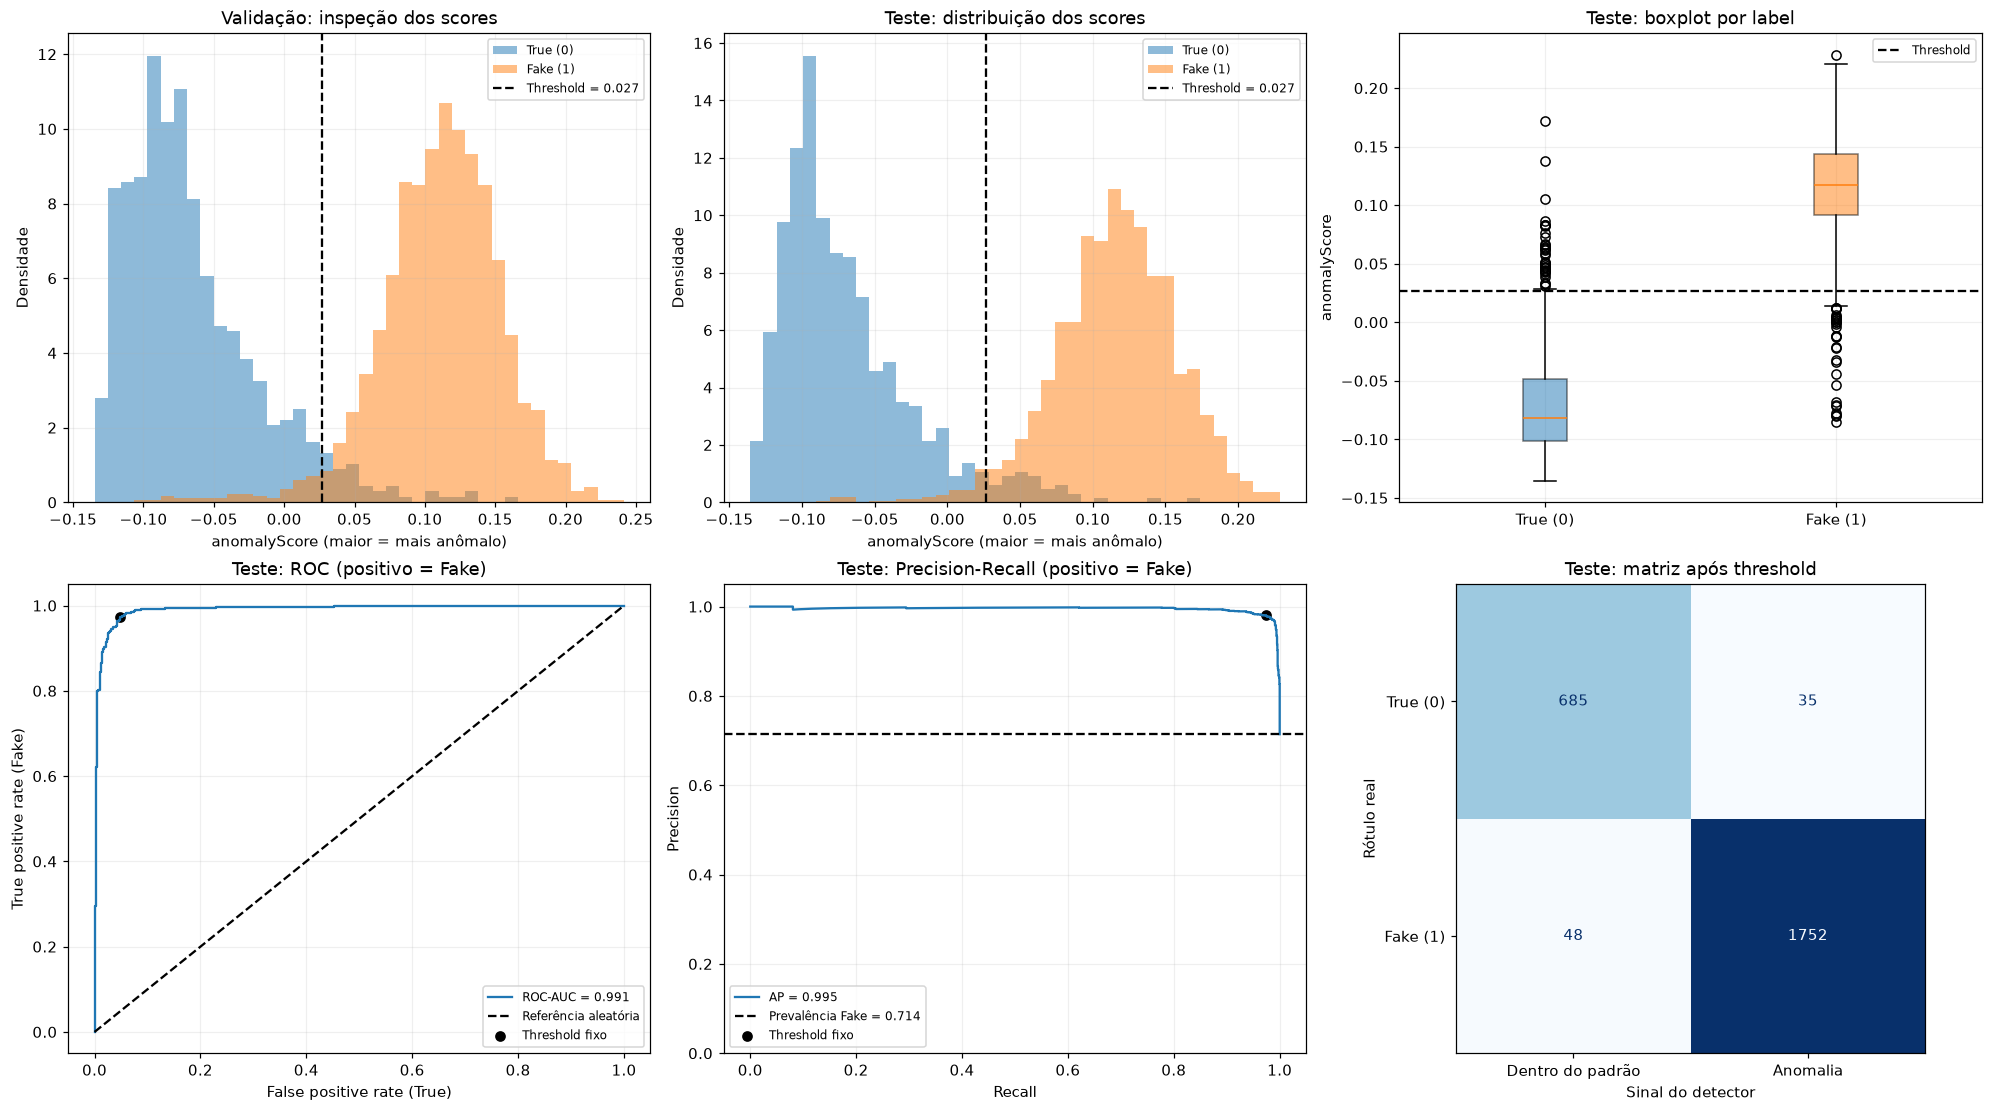

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
trueScores = testResultsFrame.loc[testResultsFrame["label"].eq(0), "anomalyScore"]
fakeScores = testResultsFrame.loc[testResultsFrame["label"].eq(1), "anomalyScore"]

for axis, groups, title in [
    (axes[0, 0], [normalValidationScores, fakeValidationScores], "Validação: inspeção dos scores"),
    (axes[0, 1], [trueScores, fakeScores], "Teste: distribuição dos scores"),
]:
    bins = np.histogram_bin_edges(np.concatenate(groups), bins=40)
    for values, name, color in zip(groups, ["True (0)", "Fake (1)"], ["tab:blue", "tab:orange"]):
        axis.hist(values, bins=bins, density=True, alpha=0.5, label=name, color=color)
    axis.axvline(threshold, color="black", linestyle="--", label=f"Threshold = {threshold:.3f}")
    axis.set(title=title, xlabel="anomalyScore (maior = mais anômalo)", ylabel="Densidade")
    axis.legend(fontsize=8)

boxes = axes[0, 2].boxplot([trueScores, fakeScores], patch_artist=True)
for box, color in zip(boxes["boxes"], ["tab:blue", "tab:orange"]):
    box.set_facecolor(color)
    box.set_alpha(0.5)
axes[0, 2].set_xticks([1, 2], ["True (0)", "Fake (1)"])
axes[0, 2].axhline(threshold, color="black", linestyle="--", label="Threshold")
axes[0, 2].set(title="Teste: boxplot por label", ylabel="anomalyScore")
axes[0, 2].legend(fontsize=8)

rocFpr, rocTpr, _ = roc_curve(testLabels, testScores, pos_label=1)
axes[1, 0].plot(rocFpr, rocTpr, label=f"ROC-AUC = {metrics['ROC-AUC']:.3f}")
axes[1, 0].plot([0, 1], [0, 1], "k--", label="Referência aleatória")
axes[1, 0].scatter([falsePositiveRate], [fakeDetectionRate], color="black", label="Threshold fixo")
axes[1, 0].set(title="Teste: ROC (positivo = Fake)", xlabel="False positive rate (True)", ylabel="True positive rate (Fake)")
axes[1, 0].legend(fontsize=8)

prPrecision, prRecall, _ = precision_recall_curve(testLabels, testScores, pos_label=1)
axes[1, 1].plot(prRecall, prPrecision, label=f"AP = {metrics['Average Precision (AP)']:.3f}")
axes[1, 1].axhline(fakePrevalence, color="black", linestyle="--", label=f"Prevalência Fake = {fakePrevalence:.3f}")
axes[1, 1].scatter([metrics["Recall"]], [metrics["Precision"]], color="black", label="Threshold fixo")
axes[1, 1].set(title="Teste: Precision-Recall (positivo = Fake)", xlabel="Recall", ylabel="Precision", ylim=(0, 1.05))
axes[1, 1].legend(fontsize=8)

ConfusionMatrixDisplay(confusionMatrix, display_labels=["True (0)", "Fake (1)"]).plot(
    ax=axes[1, 2], colorbar=False, cmap="Blues", values_format="d",
)
axes[1, 2].set_xticks([0, 1], ["Dentro do padrão", "Anomalia"])
axes[1, 2].set(title="Teste: matriz após threshold", xlabel="Sinal do detector", ylabel="Rótulo real")
axes[1, 2].grid(False)
plt.show()

## 15. Casos extremos

Exemplos exclusivamente do teste: cinco True com maior score, cinco Fake com
maior score e cinco Fake com menor score. Todas as 15 features são apresentadas;
não são atribuições causais ou importâncias do Isolation Forest. NaN exibido
na tabela corresponde à feature antes da imputação, preservada para auditoria.

In [22]:
exampleColumns = ["id", "label", "anomalyScore", "isAnomaly"] + anomalyColumns
extremeCases = {
    "5 True com maior anomalyScore": testResultsFrame.loc[testResultsFrame["label"].eq(0)].nlargest(5, "anomalyScore"),
    "5 Fake com maior anomalyScore": testResultsFrame.loc[testResultsFrame["label"].eq(1)].nlargest(5, "anomalyScore"),
    "5 Fake com menor anomalyScore": testResultsFrame.loc[testResultsFrame["label"].eq(1)].nsmallest(5, "anomalyScore"),
}
for title, examples in extremeCases.items():
    display(Markdown(f"**{title}**"))
    display(examples[exampleColumns].reset_index(drop=True))

**5 True com maior anomalyScore**

,id,label,anomalyScore,isAnomaly,tem_autor,typeTokenRatio,adjectiveRatio,adverbRatio,pronounRatio,modalVerbRatio,imperativeSubjunctiveRatio,personalPronounRatio,linkDensity,punctuationDensity,uppercaseRatio,pausalidade,pct_erros_ortograficos,emotividade,diversidade
0,262t,0,0.171806,True,0,0.141230,0.031211,0.008739,0.022472,0.024390,0.048780,0.000000,NaN,0.391800,0.018727,46.90910,0.001248,0.081425,0.232210
1,597t,0,0.137873,True,1,0.308217,0.008487,0.012981,0.008487,0.058824,0.058824,0.000000,0.0,0.349464,0.060909,51.23810,0.000000,0.036074,0.473789
2,269t,0,0.105630,True,0,0.544928,0.063158,0.038596,0.101754,0.045455,0.000000,0.000000,NaN,0.173913,0.014035,3.15789,0.007018,0.237705,0.659649
3,21t,0,0.086461,True,1,0.276486,0.037736,0.022013,0.113208,0.074074,0.111111,0.166667,0.0,0.178295,0.000000,3.45000,0.000000,0.130137,0.336478
4,3196t,0,0.082974,True,1,0.284248,0.051757,0.087269,0.157915,0.117647,0.043643,0.275120,0.0,0.150786,0.000378,2.37374,0.001889,0.346843,0.334719


**5 Fake com maior anomalyScore**

,id,label,anomalyScore,isAnomaly,tem_autor,typeTokenRatio,adjectiveRatio,adverbRatio,pronounRatio,modalVerbRatio,imperativeSubjunctiveRatio,personalPronounRatio,linkDensity,punctuationDensity,uppercaseRatio,pausalidade,pct_erros_ortograficos,emotividade,diversidade
0,2238,1,0.228568,True,0,0.637681,0.090909,0.109091,0.072727,0.000000,0.000000,0.0,0.0,0.202899,0.000000,1.400000,0.036364,0.423077,0.800000
1,3453,1,0.220715,True,0,0.663551,0.100000,0.100000,0.037500,0.214286,0.000000,0.0,0.0,0.252336,0.000000,2.700000,0.025000,0.432432,0.887500
2,3025,1,0.220547,True,0,0.606796,0.013158,0.013158,0.019737,0.294118,0.117647,0.0,0.0,0.262136,0.059211,6.000000,0.000000,0.053333,0.822368
3,3521,1,0.220084,True,0,0.900000,0.105263,0.052632,0.000000,0.000000,0.000000,NaN,0.0,0.050000,0.052632,0.250000,0.000000,0.428571,0.947368
4,3228,1,0.219909,True,0,0.857143,0.083333,0.000000,0.000000,0.500000,0.000000,NaN,0.0,0.142857,0.083333,0.666667,0.083333,0.125000,1.000000


**5 Fake com menor anomalyScore**

,id,label,anomalyScore,isAnomaly,tem_autor,typeTokenRatio,adjectiveRatio,adverbRatio,pronounRatio,modalVerbRatio,imperativeSubjunctiveRatio,personalPronounRatio,linkDensity,punctuationDensity,uppercaseRatio,pausalidade,pct_erros_ortograficos,emotividade,diversidade
0,29,1,-0.085226,False,1,0.460719,0.047256,0.053354,0.074695,0.160714,0.044643,0.081633,0.000000,0.126498,0.024390,3.06452,0.004573,0.229167,0.527439
1,31,1,-0.080009,False,1,0.510638,0.049881,0.035629,0.049881,0.072464,0.028986,0.000000,0.000000,0.104255,0.011876,1.81481,0.000000,0.184615,0.570071
2,23,1,-0.079262,False,1,0.488550,0.048673,0.057522,0.061947,0.145161,0.064516,0.000000,0.002212,0.137405,0.022124,3.00000,0.000000,0.250000,0.566372
3,61,1,-0.077773,False,1,0.460317,0.032836,0.056716,0.077612,0.153846,0.000000,0.000000,0.000000,0.113757,0.017910,2.38889,0.000000,0.218978,0.519403
4,84,1,-0.071698,False,1,0.479846,0.066667,0.046667,0.053333,0.054545,0.072727,0.000000,0.000000,0.136276,0.006667,3.73684,0.000000,0.288136,0.555556


## 16. Conclusão

Resumo calculado a partir desta execução, sem ajuste posterior de modelo ou
threshold. AUC resume ordenação; Recall/FPR resumem o corte escolhido. Nem uma
AUC acima de 0,5 demonstra significância estatística, nem um score alto prova
falsidade. Não estimamos intervalos de confiança nesta V1.

In [23]:
trueMean = scoreStatistics.loc[0, "mean"]
fakeMean = scoreStatistics.loc[1, "mean"]
trueMedian = scoreStatistics.loc[0, "median"]
fakeMedian = scoreStatistics.loc[1, "median"]
ttrWordCorrelation = lengthCorrelations.loc[("All", "typeTokenRatio"), "num_palavras"]
ttrTokenCorrelation = lengthCorrelations.loc[("All", "typeTokenRatio"), "num_tokens"]
trueAuthorRate = normalFrame["tem_autor"].mean()
fakeAuthorRate = fakeFrame["tem_autor"].mean()
trueLinkMissingCount = normalFrame["linkDensity"].isna().sum()
orderingStatement = (
    "Há sinal de ordenação na direção da hipótese neste teste (ROC-AUC acima de 0,5)."
    if metrics["ROC-AUC"] > 0.5
    else "As features atuais não produzem sinal discriminativo na direção da hipótese neste teste (ROC-AUC <= 0,5)."
)
display(Markdown(f"""
Foram treinadas **{len(normalTrainFrame)} notícias True e nenhuma Fake**.
O corte **{threshold:.6f}** foi definido por {len(normalValidationFrame)} notícias
True de validação. O teste contém **{len(normalTestFrame)} True e {len(fakeTestFrame)} Fake**.

Score médio: True **{trueMean:.4f}**, Fake **{fakeMean:.4f}**.
Mediana: True **{trueMedian:.4f}**, Fake **{fakeMedian:.4f}**.
**ROC-AUC {metrics['ROC-AUC']:.4f}**; **AP {metrics['Average Precision (AP)']:.4f}**
(prevalência Fake de referência **{fakePrevalence:.2%}**). {orderingStatement}

No threshold fixo, **{fakeDetectionRate:.2%}** das Fake são detectadas como anômalas,
enquanto **{falsePositiveRate:.2%}** das True também são sinalizadas.
Precision **{metrics['Precision']:.2%}**, Recall **{metrics['Recall']:.2%}** e
F1 **{metrics['F1']:.4f}**. Permanecem **{falseNegative} Fake sem sinal de anomalia**
e **{falsePositive} True sinalizadas**: estes erros limitam o uso isolado do detector.

TTR versus comprimento no corpus: Pearson com palavras **{ttrWordCorrelation:.3f}**
e com tokens **{ttrTokenCorrelation:.3f}**. Razões não garantem independência de
comprimento; a dependência observada aqui é forte, inclusive dentro de cada
classe (ver tabela), e pode contribuir para a separação. A correlação
TTR/diversidade é **{featureCorrelations.loc['typeTokenRatio', 'diversidade']:.3f}**;
ambas foram mantidas conforme o protocolo, sem seleção guiada pelo teste.

Há ainda uma diferença marcante de coleta/metadados: **{trueAuthorRate:.2%} das
True têm autor registrado, contra {fakeAuthorRate:.2%} das Fake**. Isso pode
favorecer separação específica deste corpus, sem medir a veracidade do conteúdo.
`linkDensity` tem **{trueLinkMissingCount} ausentes entre True** e todos os valores
observados dessa classe são zero nesta execução; depois da imputação, é constante
no treino e não oferece divisões às árvores. Não fizemos ablação: não atribuímos
causalmente o desempenho a nenhuma feature individual.

**Limites:** um único split aleatório; corpus específico e balanceado na origem;
teste com prevalência própria; possíveis efeitos de fonte, autor, época e tamanho;
pares temáticos potencialmente distribuídos entre partições. A exploração do
corpus completo não guiou ajustes nesta execução. Generalização para outras fontes,
épocas e URLs não foi testada. Não usamos este teste para otimizar o experimento.

**Anomalia não é sinônimo de falsidade.** Este resultado mede somente o quanto
os sinais linguísticos se afastam do perfil aprendido das notícias verdadeiras.
"""))


Foram treinadas **2160 notícias True e nenhuma Fake**.
O corte **0.026584** foi definido por 720 notícias
True de validação. O teste contém **720 True e 1800 Fake**.

Score médio: True **-0.0694**, Fake **0.1154**.
Mediana: True **-0.0814**, Fake **0.1172**.
**ROC-AUC 0.9908**; **AP 0.9951**
(prevalência Fake de referência **71.43%**). Há sinal de ordenação na direção da hipótese neste teste (ROC-AUC acima de 0,5).

No threshold fixo, **97.33%** das Fake são detectadas como anômalas,
enquanto **4.86%** das True também são sinalizadas.
Precision **98.04%**, Recall **97.33%** e
F1 **0.9769**. Permanecem **48 Fake sem sinal de anomalia**
e **35 True sinalizadas**: estes erros limitam o uso isolado do detector.

TTR versus comprimento no corpus: Pearson com palavras **-0.780**
e com tokens **-0.782**. Razões não garantem independência de
comprimento; a dependência observada aqui é forte, inclusive dentro de cada
classe (ver tabela), e pode contribuir para a separação. A correlação
TTR/diversidade é **0.980**;
ambas foram mantidas conforme o protocolo, sem seleção guiada pelo teste.

Há ainda uma diferença marcante de coleta/metadados: **97.97% das
True têm autor registrado, contra 2.00% das Fake**. Isso pode
favorecer separação específica deste corpus, sem medir a veracidade do conteúdo.
`linkDensity` tem **1393 ausentes entre True** e todos os valores
observados dessa classe são zero nesta execução; depois da imputação, é constante
no treino e não oferece divisões às árvores. Não fizemos ablação: não atribuímos
causalmente o desempenho a nenhuma feature individual.

**Limites:** um único split aleatório; corpus específico e balanceado na origem;
teste com prevalência própria; possíveis efeitos de fonte, autor, época e tamanho;
pares temáticos potencialmente distribuídos entre partições. A exploração do
corpus completo não guiou ajustes nesta execução. Generalização para outras fontes,
épocas e URLs não foi testada. Não usamos este teste para otimizar o experimento.

**Anomalia não é sinônimo de falsidade.** Este resultado mede somente o quanto
os sinais linguísticos se afastam do perfil aprendido das notícias verdadeiras.


## 17. Controle auxiliar: e se incluirmos num_palavras?

O modelo principal acima usa as 15 features originais SEM a contagem bruta.
Este segundo modelo usa as mesmas 15 mais num_palavras, somente para comparação.
Treino exclusivamente True, mesmos IDs e seed; cada corte vem da sua validação
True. Nenhum resultado do teste escolhe o modelo ou o corte. Esta comparação
mede o efeito da inclusão direta neste split, não prova ausência de dependência
indireta no modelo principal.

In [24]:
from sklearn.base import clone

auxiliaryColumns = anomalyColumns + ["num_palavras"]
assert normalTrainFrame["label"].eq(0).all()
auxiliaryPipeline = clone(anomalyPipeline)
auxiliaryPipeline.fit(normalTrainFrame[auxiliaryColumns])
auxiliaryValidationScores = -auxiliaryPipeline.decision_function(normalValidationFrame[auxiliaryColumns])
auxiliaryThreshold = np.quantile(auxiliaryValidationScores, 0.95)
auxiliaryScores = -auxiliaryPipeline.decision_function(testFrame[auxiliaryColumns])
auxiliaryFlags = auxiliaryScores >= auxiliaryThreshold
lengthComparison = pd.DataFrame([
    {"modelo": "Principal: SEM num_palavras", "ROC-AUC": metrics["ROC-AUC"],
     "Fake detectadas": int(truePositive), "True sinalizadas": int(falsePositive), "corte": float(threshold)},
    {"modelo": "Auxiliar: COM num_palavras", "ROC-AUC": roc_auc_score(testLabels, auxiliaryScores),
     "Fake detectadas": int(np.sum(auxiliaryFlags & (testLabels == 1))),
     "True sinalizadas": int(np.sum(auxiliaryFlags & (testLabels == 0))), "corte": float(auxiliaryThreshold)},
])
display(lengthComparison)
assert "num_palavras" not in anomalyPipeline.feature_names_in_
assert "num_palavras" in auxiliaryPipeline.feature_names_in_
print("Contagem mantida na extração; excluída do modelo principal. Comparação auxiliar concluída.")

,modelo,ROC-AUC,Fake detectadas,True sinalizadas,corte
0,Principal: SEM num_palavras,0.990782,1752,35,0.026584
1,Auxiliar: COM num_palavras,0.989457,1745,30,0.022594


Contagem mantida na extração; excluída do modelo principal. Comparação auxiliar concluída.
